# **Interpolazione polinomiale**

Lo scopo delle tecniche di interpolazione è quello di ricavare, in forma chiusa, una relazione del tipo $y=p(x)$ che catturi alcune coppie di punti $(x_{1},y_{1}),\dots,(x_{n}, y_{n})$. Tipicamente, questo problema risulta di interesse in due contesti:

*   Approssimazione di funzioni: si vuole approssimare una funzione $f$ nota con un'espressione più semplice, ad esempio in vista del calcolo numerico (si veda calcolo di integrali!).
*   Approssimazione di dati: si vuole ricostruire l'andamento di alcuni dati (ad esempio provenienti da osservazioni sperimentali, oppure dal campionamento di una funzione $f$ non nota).

Strettamente parlando, si parla di *interpolazione* se a partire dai punti viene proposta una funzione $\tilde{p}$ che passa **esattamente** dai dati sperimentali, cioè
</br></br>
\begin{equation*}y_{i}=\tilde{p}(x_{i})\quad\quad\forall i = 1,\dots, n
\end{equation*}
</br>
Si parla invece di _approssimazione ai minimi quadrati_ se l'obiettivo è quello di trovare una funzione $\hat{p}$ che minimizzi lo scarto quadratico
</br></br>
\begin{equation*}
\sum_{i=1}^{n}|y_{i}-\hat{p}(x_{i})|^{2}
\end{equation*}
</br>
all'interno di una "classe di possibili funzioni".

Oggi ci focalizzaremo su tre tipologie di interpolazione e approssimazione:

  1. Interpolazione polinomiale di Lagrange, dove $\tilde{p}$ è un polinomio di grado $n-1$
  2. Interpolazione composita (spline), dove $\tilde{p}$ è un polinomio di grado $k$ _a tratti_ (es: spezzata/spline cubica)
  3. Approssimazione polinomiale (minimi quadrati), dove $\hat{p}$ è un polinomio di grado $k<n-1$.


In [118]:
import numpy as np
import matplotlib.pyplot as plt

## **Esercizio 1: Interpolazione per l'approssimazione di funzioni**

L'interpolazione polinomiale può essere utilizzata per approssimare una data funzione $f: [a,b]\to\mathbb{R}$. In questo caso, si valuta $f$ su di una griglia con $n+1$ nodi, $\{x_{0},\dots,x_{n}\}\subset[a,b]$ e la si approssima con l'interpolante $\tilde{p}=\Pi_{n}f$ passante per i nodi $\{(x_{i}, f(x_{i}))\}_{i=0}^{n}$.
La notazione $\Pi_{n}f$ sta ad enfatizzare che l'interpolante dipende dalla funzione $f$ e dal numero di intervalli della partizione $n$.
</br></br>
La qualità dell'approssimazione può essere indagata a posteriori valutando l'errore globale
</br></br>
\begin{equation*}
E_{n}:=\max_{x\in[a,b]}|f(x)-\Pi_{n}f(x)|
\end{equation*}
</br>
sull'intervallo $[a,b]$. Come vedremo, nel caso di interpolazione polinomiale di Lagrange, la numerosità dei nodi non basta a garantire una buona approssimazione: occorre anche posizionare i nodi in modo opportuno!

<mark>**Esercizio 1.1**</mark></br>
Si consideri la funzione (chiamata **funzione di Runge**)
</br></br>
\begin{equation*}
f(x)=\frac{1}{1+x^{2}},
\end{equation*}
</br>
sull'intervallo $[a,b]=[-5,5]$. Si discuta la possibilità di interpolare $f(x)$ tramite polinomi di Lagrange. Questo può essere fatto utilizzando le funzioni **polyfit** e **polyval** della libreria **numpy**.

Si cominci rappresentando la funzione $f(x)$ e le funzioni della base di Lagrange $\mathcal{L}_i (x), i=0,...,n$. Si consideri un polinomio di interpolazione di grado 3.

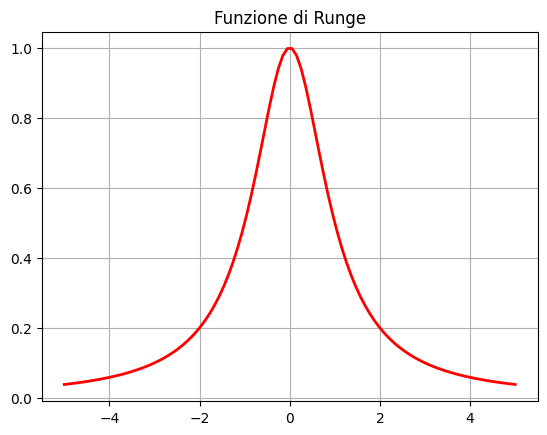

In [119]:
# Definizione di f (tramite lambda function)
def f(x): return 1.0/(1+x**2)


# Creazione dell'intervallo di punti
a = -5
b = 5
x_grid = np.linspace(a, b, 100)

# Rappresentazione di f
plt.figure()
plt.plot(x_grid, f(x_grid), 'r-', linewidth=2)
plt.title("Funzione di Runge")
plt.grid()
plt.show()

L'interpolante polinomiale di Lagrange di grado $n$ passante per $(x_i, y_i)$ con $i=0,...,n$ è definita come:

\begin{equation}
p_n(x) = \sum_{i=0}^{n} y_i \mathcal{L}_i(x),
\end{equation}

dove $\mathcal{L}_i$ costituiscono la base di Lagrange.

In [120]:
from numpy import polyfit, polyval

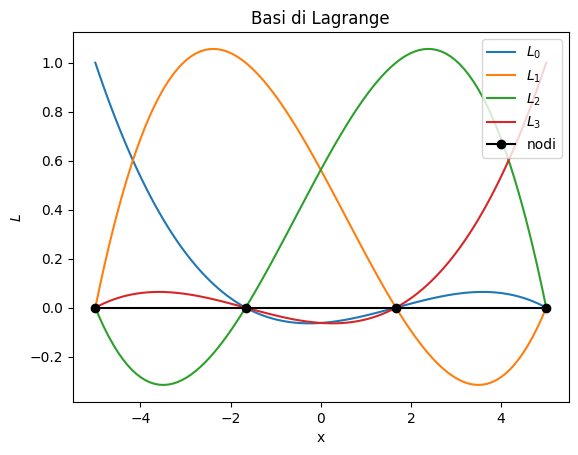

In [121]:
# Esempio della costruzione della base di Lagrange con grado n=3 usando n+1 nodi equispaziati sull'intervallo [a,b].

# grado del polinomio
deg = 3

# estremi dell'intervallo
a, b = -5, 5
# numero dei nodi
n_nodi = deg+1

# nodi nell'intervallo
x_nodi = np.linspace(a, b, n_nodi)

# punti dove valutiamo il polinomio per la rappresentazione grafica
x_grid = np.linspace(a, b, 100)

plt.figure()
# costruzione delle funzioni di base
for i in range(n_nodi):
    y_nodi = np.zeros(n_nodi)
    y_nodi[i] = 1
    # coefficienti del polinomio di grado deg che interpola i nodi
    p = polyfit(x_nodi, y_nodi, deg)
    # interpolante (definita come lambda function)
    def L(x): return polyval(p, x)
    # rappresento la i-esima base di Lagrange
    plt.plot(x_grid, L(x_grid), label='$L_{%d}$' % i)

# rappresentazione degli n+1 nodi
plt.plot(x_nodi, np.zeros(n_nodi), 'ko-', label='nodi')
plt.title("Basi di Lagrange")
plt.legend()
plt.xlabel("x")
plt.ylabel("$L$")
plt.show()

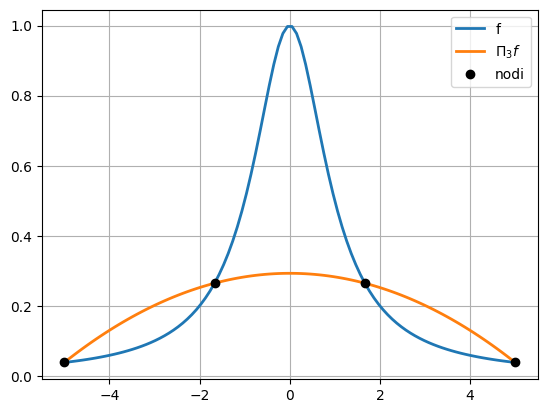

In [122]:
# Esempio di interpolazione polinomiale di Lagrange con grado n=3 usando n+1 nodi equispaziati sull'intervallo [a,b].

# x_nodi = np.linspace(a, b, n_nodi)
p = polyfit(x_nodi, f(x_nodi), deg)
def interp_Lagrange(x): return polyval(p, x)


# Rappresentazione della funzione e della interpolante negli n+1 nodi
plt.figure()
plt.plot(x_grid, f(x_grid), linewidth=2, label='f')
plt.plot(x_grid, interp_Lagrange(x_grid), linewidth=2, label='$\\Pi_3f$')
plt.plot(x_nodi, f(x_nodi), 'ko', linewidth=2, label='nodi')
plt.legend()
plt.grid()
plt.show()

<mark>**Esercizio 1.2**</mark></br>

Si provi ad aumentare il numero di nodi; in particolare, si approssimi $f$ usando l'interpolazione polinomiale di Lagrange su di una griglia equispaziata con $n=7,9,11$ intervalli. Confrontare graficamente la funzione $f$ con le varie interpolanti. Calcolare inoltre gli errori $E_{n}$ dei polinomi interpolanti rispetto alla funzione esatta.

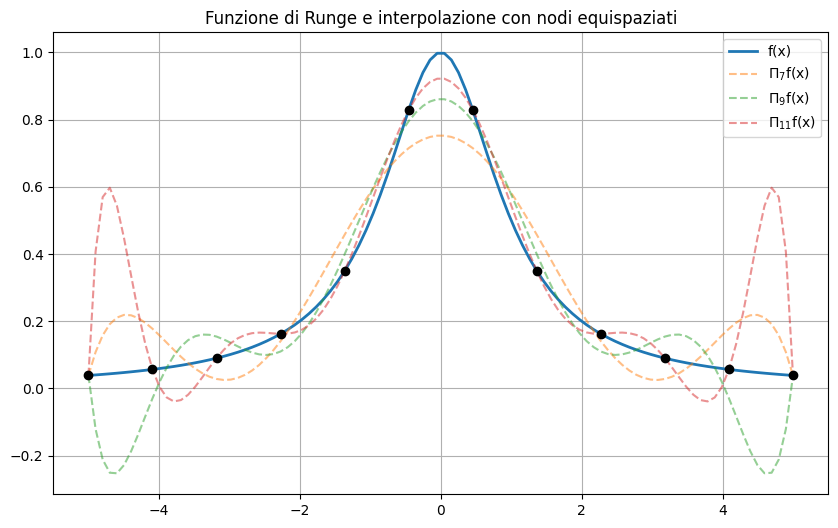

[np.float64(0.2452852703930516), np.float64(0.29797154015144667), np.float64(0.5538529081448483)]
[0.2452852703930516, 0.29797154015144667, 0.5538529081448483]


In [123]:
from numpy import linspace
num_intervalli = [7, 9, 11]

plt.figure(figsize=(10, 6))
plt.plot(x_grid, f(x_grid), linewidth=2, label='f(x)')
plt.title("Funzione di Runge e interpolazione con nodi equispaziati")
plt.grid()

# Costruzione delle interpolanti e rappresentazione
err = []

for n in num_intervalli:
    x_nodi = linspace(a, b, n+1)
    p = polyfit(x_nodi, f(x_nodi), n)
    def y(x): return polyval(p, x)
    plt.plot(x_grid, y(x_grid), '--', label='$\\Pi_{%d}$f(x)' % n, alpha=0.5)
    err.append(np.linalg.norm(f(x_grid) - y(x_grid), np.inf))

plt.plot(x_nodi, y(x_nodi), "ko")
plt.legend()
plt.show()

print(err)
print([float(x) for x in err])

<mark>**Domanda!!**</mark></br>
Che cosa sta succedendo all'aumentare di $n$? Perchè osserviamo queste oscillazioni? Discutere quello che è anche noto come **fenomeno di Runge**.

<mark>**Esercizio 1.3**</mark></br>
Si ripeta il punto precedente, utilizzando questa volta i nodi di Chebyshev. Si rammenta che, scelto $n$, sull'intervallo $\hat{I}=[-1,1]$, essi sono dati da
</br></br>
\begin{equation*}
\hat{x}_{i}=-\cos\left(\frac{\pi i}{n}\right),
\end{equation*}
</br>
dove $i=0,\dots,n$. I nodi possono essere trasferiti su un generico intervallo $[a,b]$ con la trasformazione
</br></br>
$$x_{i}=\frac{a+b}{2}+\frac{b-a}{2}\hat{x}_{i}.$$
</br>

In [124]:
def nodi_Chebyshev(a, b, n):
    """
    Calcolo degli n+1 nodi di Chebyshev sull'intervallo [a,b]
    Input:
    a: estremo sinistro dell'intervallo
    b: estremo destro dell'intervallo
    n: numero di intervalli (n+1 nodi)
    Output:
    x: nodi di Chebyshev
    """
    i = np.arange(n+1)
    x_hat = -np.cos(np.pi*i/n)
    x = (a+b)/2 + (b-a)/2 * x_hat
    return x

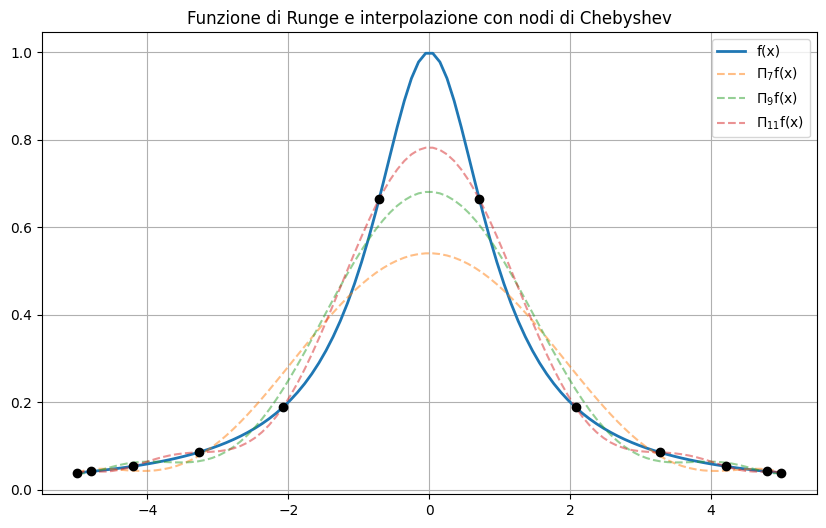

[np.float64(0.45726710067663834), np.float64(0.3169528597601584), np.float64(0.21580159559786327)]
[0.45726710067663834, 0.3169528597601584, 0.21580159559786327]


In [125]:
num_intervalli = [7, 9, 11]

plt.figure(figsize=(10, 6))
plt.plot(x_grid, f(x_grid), linewidth=2, label='f(x)')
plt.title("Funzione di Runge e interpolazione con nodi di Chebyshev")
plt.grid()

# Costruzione delle interpolanti e rappresentazione
err = []

for n in num_intervalli:
    x_nodi = nodi_Chebyshev(a, b, n)
    p = polyfit(x_nodi, f(x_nodi), n)
    def y(x): return polyval(p, x)
    plt.plot(x_grid, y(x_grid), '--', label='$\\Pi_{%d}$f(x)' % n, alpha=0.5)
    err.append(np.linalg.norm(f(x_grid) - y(x_grid), np.inf))

plt.plot(x_nodi, y(x_nodi), "ko")
plt.legend()
plt.show()

print(err)
print([float(x) for x in err])  

In presenza di nodi equispaziati, l'interpolazione polinomiale può soffrire problemi di stabilità e convergenza. Due possibili soluzioni sono date da:

*   Nodi di interpolazione non equispaziati
*   Interpolazione composita (spline) -> la vediamo applicata all'esercizio 2



## **Esercizio 2: Interpolazione per l'approsimazione di dati**
Nella tabella qui sotto riportata vengono elencati i risultati di un
esperimento eseguito per individuare il legame tra lo *sforzo* $\sigma$ e la relativa *deformazione* $\varepsilon$.
</br></br>
\begin{equation}
\begin{matrix}
\text{test}\ & \sigma \ [{\rm MPa}] & \varepsilon [\text{cm}/\text{cm}]\\
    1 & 0.00 & 0.00 \\
    2 & 0.06 & 0.08 \\
    3 & 0.14 & 0.14 \\
    4 & 0.25 & 0.20 \\
    5 & 0.31 & 0.23 \\
    6 & 0.47 & 0.25 \\
    7 & 0.60 & 0.28 \\
    8 & 0.70 & 0.29 \\
  \end{matrix}
\end{equation}
</br>
A partire da questi dati (utilizzando opportune tecniche di interpolazione e approssimazione) si vuole stimare la deformazione $ɛ$ in corrispondenza dei valori di sforzo per cui non si ha a disposizione un dato sperimentale.


<mark>**Esercizio 2.1: rappresentazione grafica dei dati**</mark></br>
Rappresentare i dati graficamente.

In [126]:
# sigma ed epsilon
sigma = [0.00, 0.06, 0.14, 0.25, 0.31, 0.47, 0.60, 0.70]
epsilon = [0.00, 0.08, 0.14, 0.20, 0.23, 0.25, 0.28, 0.29]

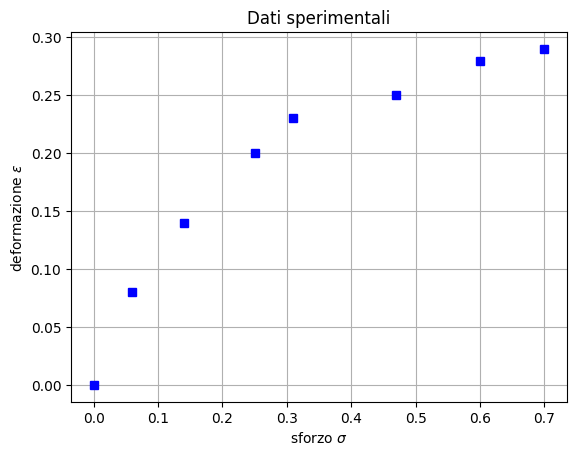

In [127]:
# Rappresentare i dati in un grafico sforzo vs deformazione
plt.figure()
plt.plot(sigma, epsilon, 'bs')
plt.xlabel("sforzo $\\sigma$")
plt.ylabel("deformazione $\\varepsilon$")
plt.title("Dati sperimentali")
plt.grid()
plt.show()

<mark>**Esercizio 2.2: interpolazione polinomiale**</mark></br>
Calcolare l'interpolante polinomiale di Lagrange, quindi confrontarla con i dati sperimentali.

**Nota**: Si rammenti che un polinomio di Lagrange interpolante $n$ dati ha grado $n-1$.

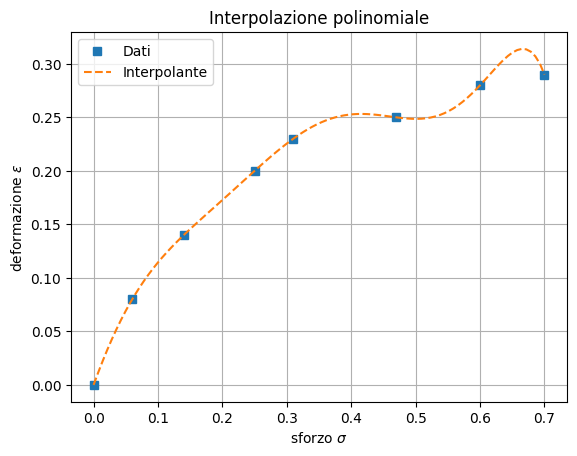

In [128]:
# Interpolazione di Lagrange e rappresentazione grafica

n = len(sigma)
p = polyfit(sigma, epsilon, n-1)
def interp_lagrange(x): return polyval(p, x)


# Nodi per la rappresentazione dell'interpolante
x_grid = linspace(min(sigma), max(sigma), 100)

plt.figure()
plt.plot(sigma, epsilon, 's', label='Dati')
plt.plot(x_grid, interp_lagrange(x_grid), '--', label='Interpolante')
plt.xlabel("sforzo $\\sigma$")
plt.ylabel("deformazione $\\varepsilon$")
plt.title("Interpolazione polinomiale")
plt.legend()
plt.grid()

<mark>**Esercizio 2.3: spline lineare**</mark></br>
Confrontare i dati sperimentali con la loro interpolante lineare a tratti (spline lineare). Si sfrutti la funzione $\texttt{interp}$ della libreria $\texttt{numpy}$.

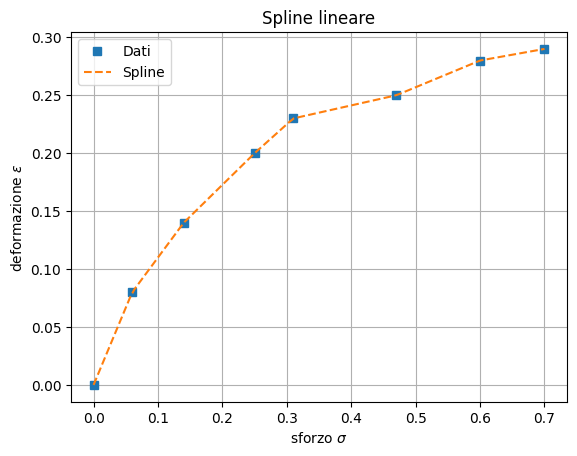

In [129]:
from numpy import interp

# Interpolazione composita (spline lineare) e rappresentazione


def spline_lineare(x): return interp(x, sigma, epsilon)


plt.figure()
plt.plot(sigma, epsilon, 's', label='Dati')
plt.plot(x_grid, spline_lineare(x_grid), '--', label="Spline")
plt.xlabel("sforzo $\\sigma$")
plt.ylabel("deformazione $\\varepsilon$")
plt.title("Spline lineare")
plt.legend()
plt.grid()

<mark>**Esercizio 2.4: spline cubica**</mark></br>
Confrontare i dati sperimentali con la loro interpolante cubica a tratti (spline cubica). Si sfrutti la classe $\texttt{CubicSpline}$ presente nel modulo $\texttt{scipy.interpolate}$.

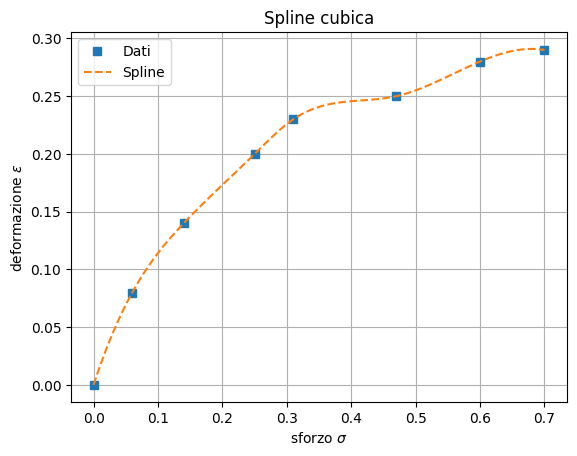

In [130]:
from scipy.interpolate import CubicSpline

# Interpolazione composita (spline cubica) e rappresentazione grafica
spline_cubica = CubicSpline(sigma, epsilon)

plt.figure()
plt.plot(sigma, epsilon, 's', label='Dati')
plt.plot(x_grid, spline_cubica(x_grid), '--', label="Spline")
plt.xlabel("sforzo $\\sigma$")
plt.ylabel("deformazione $\\varepsilon$")
plt.title("Spline cubica")
plt.legend()
plt.grid()

<mark>**Esercizio 2.5: approssimazione nel senso dei minimi quadrati**</mark></br>

Dati $n+1$ punti distinti $(x_i, y_i)$, l'approssimazione ai minimi quadrati cerca il polinomio $\hat{p}$ di grado $1<m<n$ che minimizza la distanza dai dati, ovvero tale che:

\begin{equation}
\sum_{i=0}^{n} (y_i - \hat{p}(x_i))^2 \le \sum_{i=0}^{n} (y_i - p_m(x_i))^2
\end{equation}

Confrontare i dati sperimentali con il corrispondente polinomio di grado 4 che approssima i dati nel senso dei minimi quadrati. Si sfruttino nuovamente le funzioni $\texttt{polyfit}$ e $\texttt{polyval}$ di $\texttt{numpy}$, facendo attenzione all'argomento $\texttt{deg}$.

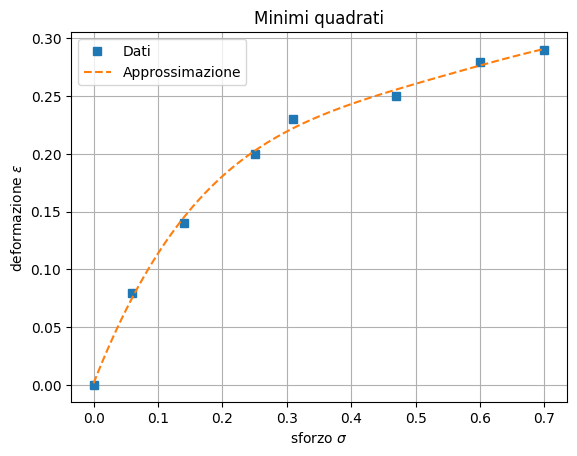

In [131]:
# Approssimazione ai minimi quadrati e rappresentazione grafica
deg = 4

p_minq = polyfit(sigma, epsilon, deg)
def minq(x): return polyval(p_minq, x)


plt.figure()
plt.plot(sigma, epsilon, 's', label='Dati')
plt.plot(x_grid, minq(x_grid), '--', label="Approssimazione")
plt.xlabel("sforzo $\\sigma$")
plt.ylabel("deformazione $\\varepsilon$")
plt.title("Minimi quadrati")
plt.legend()
plt.grid()

<mark>**Esercizio 2.6: confronto globale**</mark></br>

Confrontare, in un unico grafico, i dati sperimentali con tutte le interpolanti e approssimanti. Si commentino i risultati.

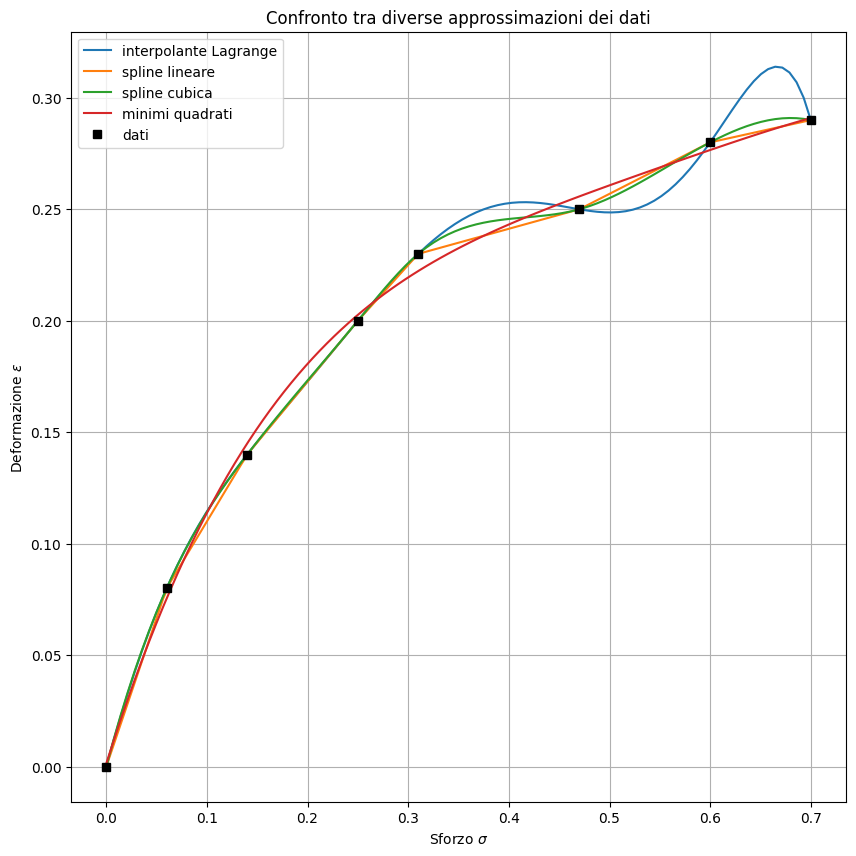

In [132]:
# Punti di valutazione
# x_grid (eventualmente ridefinire)

# Confronto
plt.figure(figsize=(10, 10))

# Interpolante di Lagrange
plt.plot(x_grid, interp_lagrange(x_grid), label='interpolante Lagrange')

# Spline lineare
plt.plot(x_grid, spline_lineare(x_grid), label='spline lineare')

# Spline cubica
plt.plot(x_grid, spline_cubica(x_grid), label='spline cubica')

# Minimi quadrati
plt.plot(x_grid, minq(x_grid), label='minimi quadrati')

# Dati
plt.plot(sigma, epsilon, 'ks', label='dati')

plt.legend()
plt.title("Confronto tra diverse approssimazioni dei dati")
plt.grid()
plt.xlabel("Sforzo $\\sigma$")
plt.ylabel("Deformazione $\\varepsilon$")
plt.show()

**Commento:** Nella figura sopra è riportato il confronto grafico tra tutte le interpolanti, da cui si nota che, rispetto alle altre, l'interpolazione polinomiale di Lagrange è la meno adatta a descrivere il legame sforzi-deformazioni, in quanto presenta un andamento oscillante ad un estremo. Le altre interpolazioni sembrano invece avere andamenti qualitativamente migliori. In particolare l'interpolazione lineare composita risulta ideale, in quanto fornisce un dato di prima approssimazione del valore incognito senza introdurre alcun tipo di oscillazione. La spline cubica, invece, sebbene produca una curva più regolare, può introdurre delle oscillazioni, che in alcuni casi portano a valori al di fuori dei limiti previsti dal buon senso, ma non è questo il caso. Infine, l'approssimazione ai minimi quadrati non interpola i dati sperimentali, me coglie molto bene l'andamento (spesso questa strategia risulta la migliore per l'approssimazione di dati).

<mark>**Esercizio 2.7: confronto approssimazioni in extra points**</mark></br>

Confrontare le approssimazioni proposte dalle tre interpolanti  e dell'approssimazione ai minimi quadrati quando $\sigma=0.4 \text{ MPa}$ e $\sigma=0.75 \text{ MPa}$, si commentino i risultati ottenuti.

In [133]:
# Stima dei valori
print("Estrapolazione in sigma = 0.4 MPa")
print("Lagrange: %f" % interp_lagrange(0.4))
print("Spline lineare: %f" % spline_lineare(0.4))
print("Spline cubica: %f" % spline_cubica(0.4))
print("Minimi quadrati (grado 4): %f" % minq(0.4))
print("\n")
print("Estrapolazione in sigma = 0.75 MPa")
print("Lagrange: %f" % interp_lagrange(0.75))
print("Spline lineare: %f" % spline_lineare(0.75))
print("Spline cubica: %f" % spline_cubica(0.75))
print("Minimi quadrati (grado 4): %f" % minq(0.75))

Estrapolazione in sigma = 0.4 MPa
Lagrange: 0.252747
Spline lineare: 0.241250
Spline cubica: 0.245656
Minimi quadrati (grado 4): 0.243183


Estrapolazione in sigma = 0.75 MPa
Lagrange: 0.080963
Spline lineare: 0.290000
Spline cubica: 0.278108
Minimi quadrati (grado 4): 0.296416


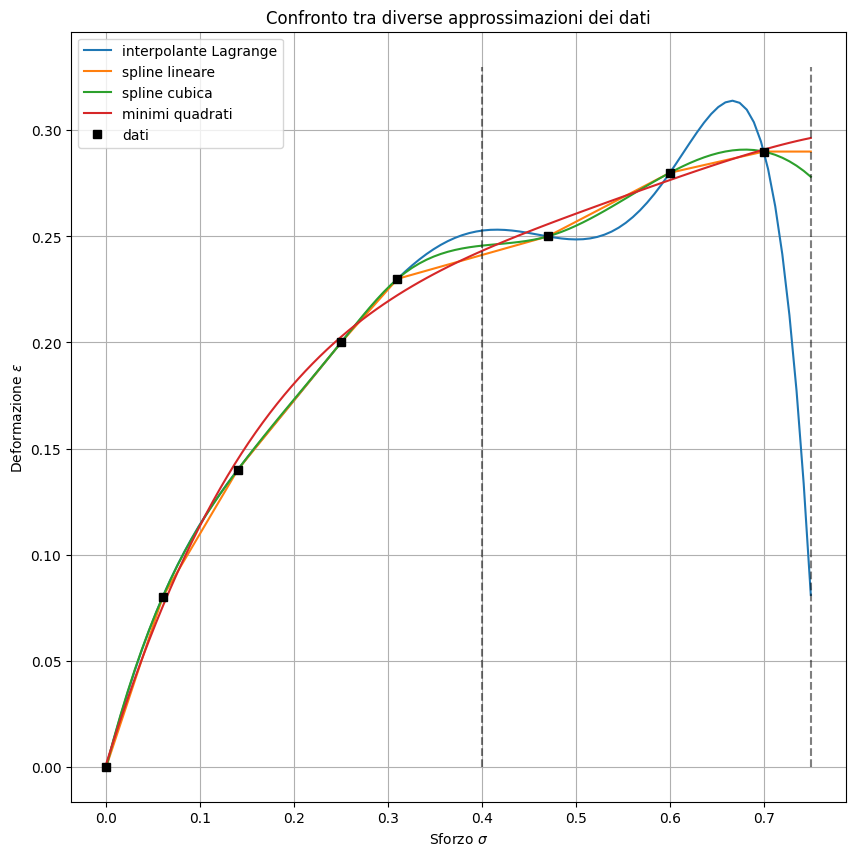

In [134]:
# Confronto grafico

# Punti di valutazione
a, b = min(sigma), 0.75
x_grid = linspace(a, b, 100)

# Confronto
plt.figure(figsize=(10, 10))

# Interpolante di Lagrange
plt.plot(x_grid, interp_lagrange(x_grid), label='interpolante Lagrange')

# Spline lineare
plt.plot(x_grid, spline_lineare(x_grid), label='spline lineare')

# Spline cubica
plt.plot(x_grid, spline_cubica(x_grid), label='spline cubica')

# Minimi quadrati
plt.plot(x_grid, minq(x_grid), label='minimi quadrati')

# Dati
plt.plot(sigma, epsilon, 'ks', label='dati')

plt.plot([0.4, 0.4], [0, 0.33], 'k--', alpha=0.5)
plt.plot([0.75, 0.75], [0, 0.33], 'k--', alpha=0.5)

plt.legend()
plt.title("Confronto tra diverse approssimazioni dei dati")
plt.grid()
plt.xlabel("Sforzo $\\sigma$")
plt.ylabel("Deformazione $\\varepsilon$")
plt.show()

**Commento:** I risultati confermano quanto detto in precedenza. In particolare l'interpolazione polinomiale di Lagrange risulta inadeguata per rappresentare la legge tra sforzi e deformazioni, con valori elevati di sforzo. Per $\sigma = 0.40 \ {\rm MPa}$ l'interpolazione composita lineare, l'approssimante ai minimi quadrati di grado $4$
 e la spline cubica forniscono valutazioni ragionevoli. Tuttavia l'interpolante composita lineare è una funzione solamente $C^0$ sull'intervallo considerato, mentre l'approssimante ai minimi quadrati e la spline garantisce una maggiore regolarità essendo una funzione $C^2$. Discorso analogo può essere ripetuto per il valore $\sigma = 0.75 \ {\rm MPa}$, dove tuttavia emergono i limiti della interpolazione lineare composita che non fornisce un valore costante a causa della sua natura.

## **Esercizi per casa**

<mark>**Esercizio 3**</mark></br>
Si consideri la funzione $f(x) = x \sin(x)$.

  1.  Si disegni  il grafico della funzione $f(x)$ nell'intervallo $[-2,6]$.
  2. Si costruiscano i polinomi interpolanti di Lagrange $\Pi_{n}f$ di grado $n=2,\,4,\,6$ relativi ad una distribuzione di nodi  equispaziati.
  3. Si rappresenti graficamente l'andamento dell'errore
$\varepsilon(x)=|f(x)-\Pi_{n}f(x)|$ e si calcoli la norma infinito:

$$
\parallel \varepsilon(x)\parallel_{\infty}=\max_{x\in[-2,6]}|f(x)-\Pi_{n}f(x)|.
$$

Commentare i risultati.

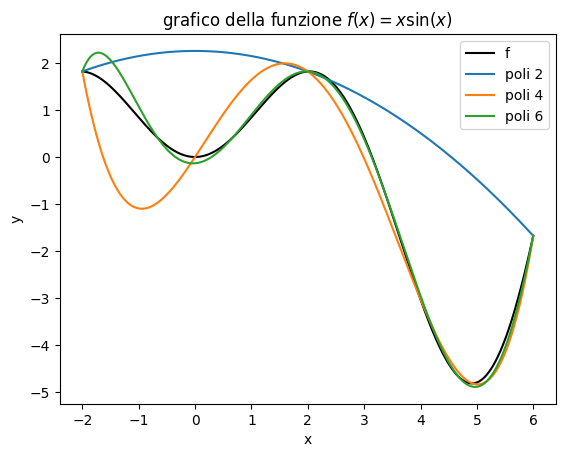

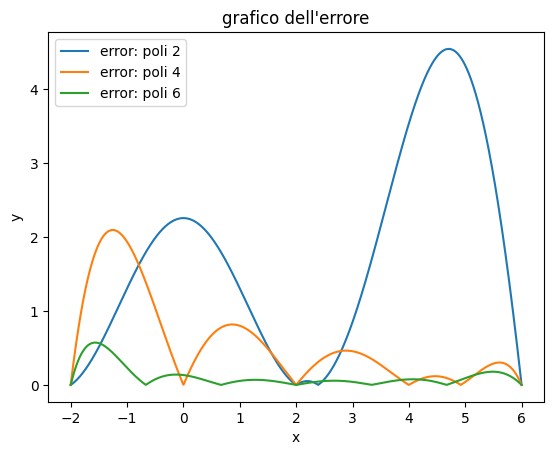

In [135]:
# rappresentazione grafica di f
import matplotlib.pyplot as plt
import numpy as np
from numpy import linspace, polyval, polyfit

# usa la lambda function per rappresentare la f


def f(x): return x*np.sin(x)


# estremi dell'intervallo
a, b = -2, 6
xx = linspace(a, b, 1000)

# plto della funzione f
plt.plot(xx, f(xx), 'k-', label='f')
# inizializzo le liste degli errori
err = []
errorMax = []

deg = [2, 4, 6]
# ciclo for
for i in deg:
    x_nodi = linspace(a, b, i+1)
    p = polyfit(x_nodi, f(x_nodi), i)
    def interpolante(x): return polyval(p, x)
    plt.plot(xx, interpolante(xx), label='poli %d' % i)
    err.append(abs(f(xx)-interpolante(xx)))
    errorMax.append(np.max(err))

plt.title("grafico della funzione $f(x) = x\\sin(x)$")
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

plt.figure(2)
j = 0
for i in deg:
    plt.plot(xx, err[j], label='error: poli %d' % i)
    j = j+1

plt.title("grafico dell'errore")
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

**Commento:** Nella prima figura si possono vedere a confronto i grafici della funzione e dei polinomi interpolatori di grado 2, 4, 6. Nella seconda figura si osserva l'andamento dell'errore e quello che si può notare è che questo diminuisce all'aumentare del grado del polinomio di interpolazione. Si osserva che aumentando il grado del polinomio interpolatore si riesce, in questo caso, ad approssimare meglio la funzione richiesta.